In [3]:
import pandas as pd
df = pd.read_csv("ab_data.csv")

In [4]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [5]:
df.tail()

,user_id,timestamp,group,landing_page,converted
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0
294477,715931,2017-01-16 12:40:24.467417,treatment,new_page,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [7]:
df.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Data Loading and Initial Inspection

The dataset was successfully loaded for analysis. Initial exploration was performed using functions such as `head()`, `tail()`, and `info()` to understand the structure and contents of the data.

The dataset contains 5 columns: user_id, timestamp, group, landing_page, and converted.

Further checks were conducted to ensure data quality:
- No missing values were found in the dataset.
- No duplicate records were detected.

This confirms that the dataset is clean and ready for further analysis.

In [10]:
control = df[df['group']=='control']['converted']
treatment = df[df['group']=='treatment']['converted']
control_mean = control.mean()
treatment_mean = treatment.mean()

print("Control Group Conversion Rate:", control_mean*100, "%")
print("Treatment Group Conversion Rate:", treatment_mean*100, "%")


Control Group Conversion Rate: 12.039917935897611 %
Treatment Group Conversion Rate: 11.891957956489856 %


## Conversion Rate Analysis

The conversion rates for both groups were calculated:

- Control Group (A): 12.03%
- Treatment Group (B): 11.89%

This shows that the `control` group has a slightly higher conversion rate. However, further statistical testing is required to determine whether this difference is significant.

In [11]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(control, treatment)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.2369207675839398
p-value: 0.2161174856249083


## Hypothesis Testing Conclusion

A t-test was conducted to compare the conversion rates of the control and treatment groups.

- t-statistic = 1.2369  
- p-value = 0.2161  

Since the p-value is greater than 0.05, we fail to reject the null hypothesis. This indicates that the observed difference in conversion rates is not statistically significant.

Therefore, there is no sufficient evidence to conclude that the new version (treatment) performs better than the old version (control). The existing version should be retained.

In [ ]:
pip install matplotlib

Matplotlib is building the font cache; this may take a moment.


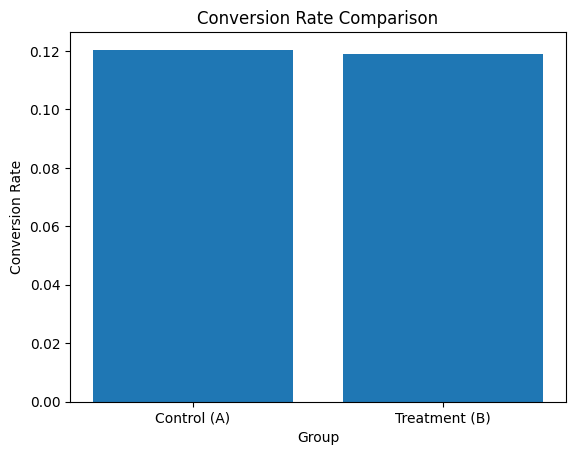

In [14]:
import matplotlib.pyplot as plt

labels = ['Control (A)', 'Treatment (B)']
values = [control_mean, treatment_mean]

plt.figure()
plt.bar(labels, values)
plt.title("Conversion Rate Comparison")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")

plt.show()

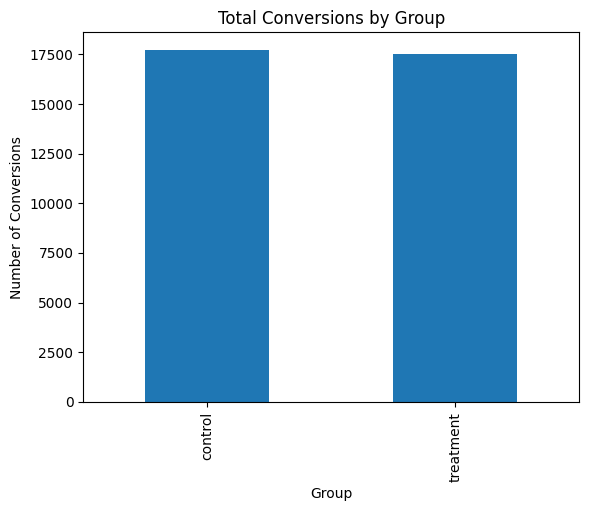

In [15]:
df.groupby('group')['converted'].sum().plot(kind='bar')

plt.title("Total Conversions by Group")
plt.ylabel("Number of Conversions")
plt.xlabel("Group")

plt.show()

In [ ]:
pip install seaborn

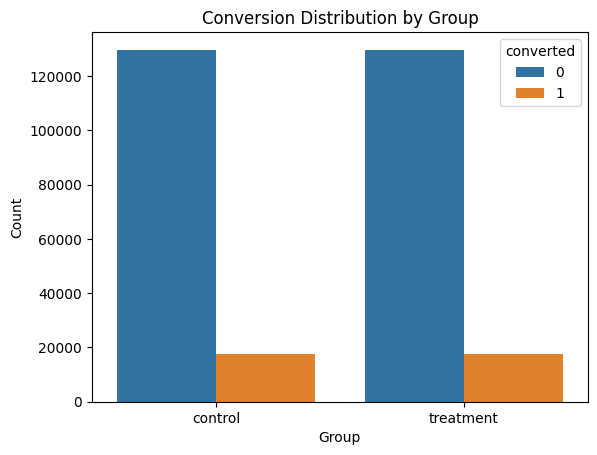

In [18]:
import seaborn as sns

plt.figure()
sns.countplot(x='group', hue='converted', data=data)

plt.title("Conversion Distribution by Group")
plt.xlabel("Group")
plt.ylabel("Count")

plt.show()

## Data Visualization

To better understand the performance of both groups, visualizations were created to compare conversion rates and distribution of conversions.

From the bar chart, the control group appears to have a slightly higher conversion rate than the treatment group. However, the difference is extremely small and not easily distinguishable visually, as both bars are nearly identical in height.

This visual observation suggests that the performance of both groups is very similar. This aligns with the statistical test results, which indicate that the difference is not statistically significant.